## **MLP implementada manualmente: Aprendendo função XOR**

Esse notebook visa implementar uma MLP simples, para aprender a função **XOR**.

> O prof. Gabriel disse que eu devia implementar uma MLP na mão — sem ser nutella e usar *pytorch*.

Só revisando, a função **XOR** recebe dois valores $x_1$ e $x_2$, pertencendes ao conjunto $\{0, 1\}$, e mapeia para as saídas:

| $x_2$ | $x_2$ | Output |
|---|---|---|
| $1$ | $1$ | $0$ |
| $1$ | $0$ | $1$ |
| $0$ | $1$ | $1$ |
| $0$ | $0$ | $0$ |

É um problema que só uma MLP pode resolver, pois **não é linearmente separável**.

#### **Dataset**

In [ ]:
X = [
    [0,  0],
    [0,  1],
    [1,  0],
    [1,  1],
]

T = [0, 1, 1, 0]

#### **Modelo**

O modelo é definido com as seguinte sequência de camadas:

$$
\text{model} = \bigl(
    \underbrace{\text{Linear}(2,2)}_{\mathbf{W}^{(1)} \in \mathbb{R}^{2\times2},\; \mathbf{b}^{(1)} \in \mathbb{R}^{2}},\;
    \sigma,\;
    \underbrace{\text{Linear}(2,1)}_{\mathbf{W}^{(2)} \in \mathbb{R}^{1\times2},\; \mathbf{b}^{(2)} \in \mathbb{R}^{1}},\;
    \sigma
\bigr)
$$

Onde $\sigma$ é a função de ativação sigmoid.

##### **Funções auxiliares**

In [ ]:
import numpy as np

def sigmoid(a):
    return 1 / (1 + np.exp(-a))

def sigmoid_der(a):
    s = sigmoid(a)
    return s * (1 - s)

### **Treinamento do Modelo**

#### **Forward**

In [ ]:
W1 = np.random.randn(2, 3) * (1 / 3**0.5)
W2 = np.random.randn(1, 3) * (1 / 3**0.5)

In [ ]:
def forward(x):
  """
  Input: Um vetor x = [x1, x2]
  Output: Logits brutos z0, a1, z1, a2, z2

  Essa função calcula a pré-ativação e ativação para cada nó em cada camada da rede.
  """

  z0 = [1] + x

  a1 = [
      sum(W1[j][i] * z0[i] for i in range(3))
      for j in range(2)
  ]

  z1 = [1] + [sigmoid(a1[j]) for j in range(2)]

  a2 = [
      sum(W2[j][i] * z1[i] for i in range(3))
      for j in range(1)
  ]

  z2 = [sigmoid(a2[k]) for k in range(1)]

  return z0, a1, z1, a2, z2

#### **Backward**

In [ ]:
def backward(z0, a1, z1, a2, z2, t, lr):
  """
  Input: Logits brutos: z0, a1, z1, a2, z2; o valor real da amostra e o learning rate
  Output: Atualiza os pesos de cada camada

  Essa função calcula a pré-ativação e ativação para cada nó em cada camada da rede.
  """
  y = z2

  delta2 = [z2[k] - t for k in range(1)]

  delta1 = [
      sigmoid_der(a1[j]) * sum(W2[k][j + 1] * delta2[k] for k in range(1))
      for j in range(2)
  ]

  for j in range(1):
    for i in range(3):
        W2[j][i] -= lr * delta2[j] * z1[i]

  for j in range(2):
    for i in range(3):
        W1[j][i] -= lr * delta1[j] * z0[i]

#### **Loop de treinamento**

In [ ]:
import random

def bce_loss(t, y):
    eps = 1e-8
    return -(t * np.log(y + eps) + (1 - t) * np.log(1 - y + eps))

lr     = 0.5
epochs = 10000
indices = list(range(4))
losses = []

for epoch in range(epochs):
  random.shuffle(indices)
  epoch_loss = 0.0

  for n in indices:
    z0, a1, z1, a2, z2 = forward(X[n])
    backward(z0, a1, z1, a2, z2, T[n], lr)
    epoch_loss += bce_loss(T[n], z2[0])

  losses.append(epoch_loss)

  if (epoch + 1) % 1000 == 0:
        print(f"Época {epoch+1:5d} | Loss: {epoch_loss/4:.6f}")


Época  1000 | Loss: 0.019362
Época  2000 | Loss: 0.003830
Época  3000 | Loss: 0.002108
Época  4000 | Loss: 0.001451
Época  5000 | Loss: 0.001105
Época  6000 | Loss: 0.000892
Época  7000 | Loss: 0.000748
Época  8000 | Loss: 0.000643
Época  9000 | Loss: 0.000565
Época 10000 | Loss: 0.000503


#### **Curva de Aprendizado**

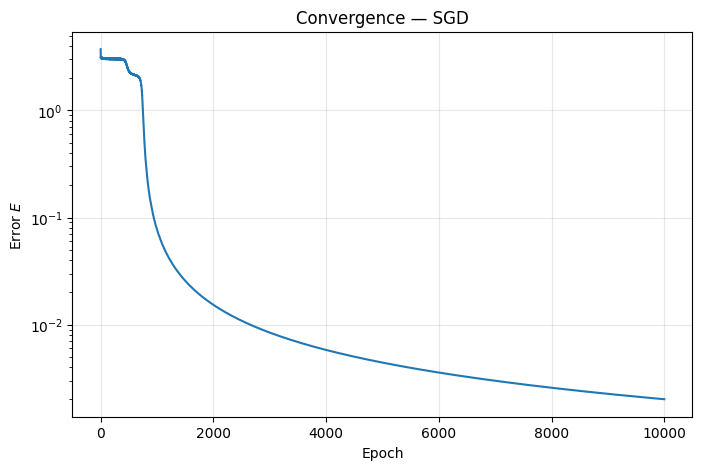

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel(r"Error $E$")
plt.title("Convergence — SGD")
plt.grid(True, alpha=0.3)
plt.yscale("log")
plt.show()

### **Predição**

In [ ]:
for n in range(4):
    _, _, _, _, z2 = forward(X[n])
    pred = 1 if z2[0] >= 0.5 else 0
    print(f"x={X[n]}, y_pred={z2[0]:.4f}, classe={pred}, target={T[n]}")

x=[0, 0], y_pred=0.0004, classe=0, target=0
x=[0, 1], y_pred=0.9995, classe=1, target=1
x=[1, 0], y_pred=0.9995, classe=1, target=1
x=[1, 1], y_pred=0.0007, classe=0, target=0
